# Sesion 9 — Pandas Avanzado + Primeras Visualizaciones
## Diplomado: Machine Learning en Seguros · FC UNAM
### Miercoles 6 de mayo de 2026  ·  18:00 - 21:00 h (3 horas)

---

> **Prerequisito:** la carpeta `sesion_8/datos/` con los archivos de S8 debe existir.

## Contenido

**Parte 1 — Tabla Maestra Actuarial (60 min)**
1. [Joins en cascada: construir la tabla maestra](#joins)
2. [Verificacion y auditoria del join](#auditoria)

**Parte 2 — Tips Profesionales de Pandas (45 min)**
3. [assign() y pipe(): codigo expresivo](#assign)
4. [query(), isin(), between()](#query)
5. [qcut(), Categorical con orden, crosstab()](#categorias)
6. [str.extract() con regex](#regex)

**Parte 3 — Matplotlib (45 min)**
7. [Anatomia de una grafica: Figure y Axes](#matplotlib)
8. [Barras, histograma, linea temporal, scatter](#graficas)
9. [Ejercicio integrador](#ejercicio)

---
<a id='joins'></a>
## Parte 1 — Tabla Maestra Actuarial


In [110]:
import pandas as pd
import numpy as np

import os

import matplotlib.pyplot as plt
import matplotlib as mpl

# Configuracion global de graficas — ejecutar una sola vez
mpl.rcParams['figure.dpi']    = 120
mpl.rcParams['font.family']   = 'sans-serif'
mpl.rcParams['axes.spines.top']  = False
mpl.rcParams['axes.spines.right'] = False



# Importar funciones de S8
import sys
from pathlib import Path

sys.path.append(str(Path('..') / 'sesion_8'))
from sesion8_soluciones import limpiar_cartera_completa, ANALITICAS

print('Funciones de S8 importadas correctamente')

Funciones de S8 importadas correctamente


In [111]:
# ── Paso 1: Cargar y limpiar la base principal ───────────────────────────────
# Usamos el pipeline completo de S8 — ya lo conocemos
cartera = limpiar_cartera_completa()
print(f'Base limpia: {cartera.shape}')

  [1/7] Cargando columnas analiticas...
        CSV: 20.6 MB → en memoria: 70.5 MB · Shape: (50000, 31)
  [2/7] Eliminando duplicados...
        Eliminados: 0 duplicados · Quedan: 50,000
  [3/7] Normalizando texto (sexo, codigo_postal)...
        Sexo normalizado. Valores no reconocidos → NaN: 0
  [4/7] Convirtiendo fechas...
        NaT generados por fechas invalidas: 0
  [5/7] Imputando prima_neta por mediana de ramo...
        Imputadas: 1000 primas → mediana de su ramo
  [6/7] Limpiando campos adicionales...
        CPs invalidos convertidos a NaN: 1500
  [7/7] Optimizando tipos de dato...
  Memoria: 61.9 MB → 14.1 MB (77% reduccion)

  ✓ Verificacion final:
    Shape:           (50000, 31)
    NaN restantes:   166289 (normales: deducible Vida, vehiculo no-Autos, etc.)
    Duplicados:      0
    Sexo sucio:      0
    Fechas como str: 0
Base limpia: (50000, 31)


In [112]:
# ── Paso 2: Join con catalogo de agentes ─────────────────────────────────────
agentes = pd.read_csv('datos/catalogo_agentes.csv')

df = pd.merge(
    cartera,
    agentes[['agente_id','nombre','region','tipo','comision_pct']].rename(
        columns={'nombre':'nombre_agente','tipo':'tipo_agente'}),
    on='agente_id',
    how='left'
)

# Verificar: no deben perderse filas en un left join con catalogo
assert len(df) == len(cartera), f'ERROR: se perdieron filas. Antes:{len(cartera)}, Despues:{len(df)}'
print(f'+ Agentes: {df.shape}  |  NaN en nombre_agente: {df["nombre_agente"].isna().sum()}')

+ Agentes: (50000, 35)  |  NaN en nombre_agente: 0


In [113]:
# ── Paso 3: Resumen de siniestros por poliza ─────────────────────────────────
# NO hacemos merge directo con la tabla de siniestros (18k filas, relacion 1-N)
# Primero AGREGAMOS por poliza, luego hacemos merge con el resultado

sins = pd.read_csv(
    'datos/siniestros.csv',

    usecols=[
        'id_poliza',
        'id_siniestro',
        'monto_reclamado',
        'monto_pagado',
        'status_siniestro',
        'tipo_siniestro'
    ],

    na_values=['N/A', '']
)

resumen_sin = sins.groupby('id_poliza').agg(
    n_siniestros    = ('id_siniestro',    'count'),
    monto_reclamado = ('monto_reclamado',  'sum'),
    monto_pagado    = ('monto_pagado',     'sum'),
    tiene_abierto   = ('status_siniestro', lambda x: (x=='En proceso').any()),
    tipo_principal  = ('tipo_siniestro',   lambda x: x.mode()[0] if len(x)>0 else None),
).reset_index()

# Join: cartera + resumen siniestros
df = pd.merge(df, resumen_sin, on='id_poliza', how='left')

# Polizas sin siniestros → NaN → 0
for col in ['n_siniestros','monto_reclamado','monto_pagado']:
    df[col] = df[col].fillna(0)
df['tiene_abierto'] = df['tiene_abierto'].fillna(False)

print(f'+ Siniestros: {df.shape}')
print(f'Polizas sin siniestros: {(df["n_siniestros"]==0).sum():,} ({(df["n_siniestros"]==0).mean():.1%})')

+ Siniestros: (50000, 40)
Polizas sin siniestros: 34,896 (69.8%)


/var/folders/0x/kxtns7515ps4lbrgywb868nw0000gn/T/ipykernel_71467/2237946603.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['tiene_abierto'] = df['tiene_abierto'].fillna(False)


<a id='auditoria'></a>
### Auditoria del join — siempre hacerla


In [114]:
# ── Auditoria — 4 verificaciones basicas despues de cada join ────────────────
print('=== AUDITORIA DE LA TABLA MAESTRA ===')
print(f'Shape final:         {df.shape}')
print(f'Filas esperadas:     {len(cartera):,}')
print(f'Filas resultado:     {len(df):,}')
print(f'Coinciden:           {len(df)==len(cartera)}')
print()

# NaN por columna nueva
cols_nuevas = ['nombre_agente','region','n_siniestros','monto_pagado']
print('NaN en columnas del join:')
for col in cols_nuevas:
    pct = df[col].isna().mean()*100
    print(f'  {col:<25}: {pct:>5.1f}%')
print()

# Distribucion por ramo para verificar que no cambio
print('Distribucion por ramo (debe ser identica a la cartera original):')
print(df['ramo'].value_counts())

=== AUDITORIA DE LA TABLA MAESTRA ===
Shape final:         (50000, 40)
Filas esperadas:     50,000
Filas resultado:     50,000
Coinciden:           True

NaN en columnas del join:
  nombre_agente            :   0.0%
  region                   :   0.0%
  n_siniestros             :   0.0%
  monto_pagado             :   0.0%

Distribucion por ramo (debe ser identica a la cartera original):
ramo
GMM                      22531
Autos                    14752
Vida                      7510
Accidentes Personales     5207
Name: count, dtype: int64


In [115]:
# ── Agregar metricas derivadas ───────────────────────────────────────────────
hoy = pd.Timestamp.today()

df = df.assign(
    # Financiero
    prima_mensual    = lambda x: x['prima_total'] / 12,
    loss_ratio       = lambda x: (x['monto_pagado'] / x['prima_total']).clip(0, 5),
    comision_est     = lambda x: x['prima_total'] * x['comision_pct'],
    # Riesgo
    nivel_riesgo     = lambda x: pd.cut(x['n_siniestros'],
                           bins=[-1,0,1,99], labels=['BAJO','MEDIO','ALTO']),
    # Temporal
    anio_emision     = lambda x: x['fecha_emision'].dt.year,
    mes_emision      = lambda x: x['fecha_emision'].dt.month,
    trimestre        = lambda x: x['fecha_emision'].dt.quarter,
)


# Categorical con orden — para que BAJO < MEDIO < ALTO funcione
df['nivel_riesgo'] = pd.Categorical(
    df['nivel_riesgo'], categories=['BAJO','MEDIO','ALTO'], ordered=True)

print(f'Tabla maestra final: {df.shape}')
print(f'Columnas: {list(df.columns)}')

Tabla maestra final: (50000, 47)
Columnas: ['id_poliza', 'num_poliza', 'nombre', 'apellido_paterno', 'apellido_materno', 'rfc', 'edad', 'sexo', 'estado_civil', 'ocupacion', 'ramo', 'plan', 'fecha_emision', 'fecha_inicio_vigencia', 'fecha_fin_vigencia', 'num_renovaciones', 'status_poliza', 'motivo_baja', 'canal_venta', 'marca_vehiculo', 'modelo_vehiculo', 'tipo_vehiculo', 'suma_asegurada', 'deducible', 'prima_neta', 'prima_total', 'forma_pago', 'agente_id', 'estado', 'municipio', 'codigo_postal', 'nombre_agente', 'region', 'tipo_agente', 'comision_pct', 'n_siniestros', 'monto_reclamado', 'monto_pagado', 'tiene_abierto', 'tipo_principal', 'prima_mensual', 'loss_ratio', 'comision_est', 'nivel_riesgo', 'anio_emision', 'mes_emision', 'trimestre']


---
<a id='assign'></a>
## Parte 2 — Tips Profesionales de Pandas

### assign() y pipe() — Codigo Expresivo

In [116]:
# ── assign(): encadenar transformaciones sin variables intermedias ───────────
# Antes (verbose, muchas variables temporales):
# df['prima_mensual'] = df['prima_total'] / 12
# df['loss_ratio']    = df['monto_pagado'] / df['prima_total']
# ...

# Despues (encadenado con assign):
df_enriquecido = (
    df
    .assign(
        prima_mensual  = lambda x: x['prima_total'] / 12,
        loss_ratio     = lambda x: (x['monto_pagado'] / x['prima_total']).clip(0, 3),
        cuartil_prima  = lambda x: pd.qcut(x['prima_total'], q=4, labels=['Q1','Q2','Q3','Q4']),
    )
)
print(df_enriquecido[['prima_total','prima_mensual','loss_ratio','cuartil_prima']].head(5).to_string(index=False))

 prima_total  prima_mensual  loss_ratio cuartil_prima
   67,651.20       5,637.60        0.00            Q4
    6,394.50         532.88        0.00            Q1
   22,049.28       1,837.44        0.00            Q3
  124,027.20      10,335.60        0.00            Q4
   62,640.00       5,220.00        0.00            Q4


In [117]:
# ── pipe(): pipeline de transformaciones como verbos ─────────────────────────
# Cada funcion recibe y devuelve un DataFrame

def solo_vigentes(df):
    n = len(df)
    df = df[df['status_poliza']=='Vigente']
    print(f'  solo_vigentes: {n:,} → {len(df):,} filas')
    return df

def agregar_segmento(df):
    df = df.assign(
        segmento = lambda x: x['ramo'].astype(str) + '-' + x['nivel_riesgo'].astype(str)
    )
    print(f'  agregar_segmento: columna segmento creada')
    return df

def optimizar_mem(df):
    for col in df.select_dtypes('object').columns:
        if df[col].nunique() / len(df) < 0.05:
            df[col] = df[col].astype('category')
    print(f'  optimizar_mem: categoricas optimizadas')
    return df



df_pipe = (
    df
    .pipe(solo_vigentes)
    .pipe(agregar_segmento)
    .pipe(optimizar_mem)
)
print(f'Resultado: {df_pipe.shape}')

  solo_vigentes: 50,000 → 45,074 filas
  agregar_segmento: columna segmento creada
  optimizar_mem: categoricas optimizadas
Resultado: (45074, 48)


<a id='query'></a>
### query(), isin(), between() — Filtros Legibles

In [118]:
# ── query(): filtros como texto natural ─────────────────────────────────────
# Equivalentes — elige el mas legible para tu equipo

# Estilo clasico
r1 = df[(df['prima_total'] > 8000) & (df['ramo'] == 'GMM') & (df['n_siniestros'] > 0)]

# Estilo query — mas legible
r2 = df.query('prima_total > 8000 and ramo == "GMM" and n_siniestros > 0')

print(f'Mismo resultado: {len(r1) == len(r2)}  ({len(r1):,} polizas)')

# Usar variable de Python dentro de query con @
umbral = 8000
ramo_objetivo = 'GMM'
r3 = df.query('prima_total > @umbral and ramo == @ramo_objetivo')
print(f'Con variables (@): {len(r3):,} polizas')

Mismo resultado: True  (5,582 polizas)
Con variables (@): 18,354 polizas


In [119]:
# ── isin() y between() ───────────────────────────────────────────────────────

# isin(): filtrar por lista de valores
ramos_salud = ['GMM', 'Accidentes Personales']
polizas_salud = df[df['ramo'].isin(ramos_salud)]
print(f'Polizas de salud: {len(polizas_salud):,}')

# NOT isin: polizas que NO son de esos ramos
no_salud = df[~df['ramo'].isin(ramos_salud)]
print(f'No salud:         {len(no_salud):,}')

# between(): rango de valores (inclusivo en ambos extremos)
prima_media = df[df['prima_total'].between(3000, 8000)]
print(f'Prima entre 3k-8k:{len(prima_media):,}')

# between() con fechas
emitidas_2024 = df[df['fecha_emision'].between('2024-01-01', '2024-12-31')]
print(f'Emitidas en 2024: {len(emitidas_2024):,}')

Polizas de salud: 27,738
No salud:         22,262
Prima entre 3k-8k:10,558
Emitidas en 2024: 8,264


<a id='categorias'></a>
### qcut(), Categorical con Orden, crosstab()

In [120]:
# ── qcut() vs cut() — la diferencia clave ────────────────────────────────────
# cut():  rangos FIJOS que tu defines
# qcut(): rangos por CUARTILES — mismo numero de filas en cada grupo

# cut() — rangos de negocio fijos
df['segmento_prima_fijo'] = pd.cut(
    df['prima_total'],
    bins=[0, 3000, 6000, 10000, float('inf')],
    labels=['Basica', 'Media', 'Alta', 'Premium']
)

# qcut() — cuartiles: cada cuartil tiene ~25% de las polizas
df['cuartil_prima'] = pd.qcut(
    df['prima_total'], q=4, labels=['Q1','Q2','Q3','Q4']
)

print('Distribucion por segmento fijo:')
print(df['segmento_prima_fijo'].value_counts())
print()
print('Distribucion por cuartil (deberia ser ~25% cada uno):')
print(df['cuartil_prima'].value_counts(normalize=True).mul(100).round(1))

Distribucion por segmento fijo:
segmento_prima_fijo
Premium    33919
Alta       10552
Media       4243
Basica      1286
Name: count, dtype: int64

Distribucion por cuartil (deberia ser ~25% cada uno):
cuartil_prima
Q1   26.20
Q4   25.00
Q3   24.80
Q2   24.10
Name: proportion, dtype: float64


In [121]:
# ── Categorical con orden — para que BAJO < MEDIO < ALTO funcione ────────────

# Sin orden: sort no funciona correctamente
print('Sin orden:', df['nivel_riesgo'].sort_values().unique())

# Con orden definido
df['nivel_riesgo'] = pd.Categorical(
    df['nivel_riesgo'],
    categories=['BAJO', 'MEDIO', 'ALTO'],
    ordered=True
)

# Ahora funciona el filtro por comparacion
polizas_medio_alto = df[df['nivel_riesgo'] >= 'MEDIO']
print(f'Polizas MEDIO o ALTO: {len(polizas_medio_alto):,}')

# Y el groupby ordena correctamente
print(df.groupby('nivel_riesgo', observed=True)['prima_total'].mean().round(2))

Sin orden: ['BAJO', 'MEDIO', 'ALTO']
Categories (3, object): ['BAJO' < 'MEDIO' < 'ALTO']
Polizas MEDIO o ALTO: 15,104
nivel_riesgo
BAJO    29,337.17
MEDIO   29,118.53
ALTO    29,351.37
Name: prima_total, dtype: float64


In [122]:
# ── crosstab(): tabla de contingencia rapida ─────────────────────────────────
# Alternativa rapida a pivot_table para conteos y proporciones

# Conteo simple
tabla = pd.crosstab(df['ramo'], df['nivel_riesgo'],
                    margins=True, margins_name='TOTAL')
print('Polizas por ramo y nivel de riesgo:')
print(tabla)
print()

# Proporciones por fila — que % de cada ramo es ALTO riesgo
tabla_pct = pd.crosstab(df['ramo'], df['nivel_riesgo'],
                        normalize='index').mul(100).round(1)
print('Distribucion % por ramo:')
print(tabla_pct)

Polizas por ramo y nivel de riesgo:
nivel_riesgo            BAJO  MEDIO  ALTO  TOTAL
ramo                                            
Accidentes Personales   3666   1280   261   5207
Autos                  10333   3647   772  14752
GMM                    15686   5676  1169  22531
Vida                    5211   1913   386   7510
TOTAL                  34896  12516  2588  50000

Distribucion % por ramo:
nivel_riesgo           BAJO  MEDIO  ALTO
ramo                                    
Accidentes Personales 70.40  24.60  5.00
Autos                 70.00  24.70  5.20
GMM                   69.60  25.20  5.20
Vida                  69.40  25.50  5.10


<a id='regex'></a>
### str.extract() con Regex

In [123]:
# ── str.extract(): descomponer el num_poliza en sus partes ───────────────────
# num_poliza tiene el formato: 'GMM-24-000123'

print('Muestra de num_poliza:')
print(df['num_poliza'].head(5).values)
print()

# Extraer ramo, anio y secuencia en UNA sola operacion con grupos con nombre
# Normalizar a mayúsculas antes de extraer
partes = df['num_poliza'].str.upper().str.extract(
    r'^(?P<cod_ramo>[A-Z]+)-(?P<anio_2dig>[0-9]{2})-(?P<secuencia>[0-9]+)'
)


print('Extracciones:')
print(partes.head(5).to_string(index=False))

# Agregar al DataFrame
df['cod_ramo'] = partes['cod_ramo']
df['anio_poliza'] = ('20' + partes['anio_2dig']).astype('Int16')

# Verificar que cod_ramo coincide con la columna ramo
mapa_cod = {'GMM':'GMM','AUT':'Autos','VID':'Vida','ACC':'Accidentes Personales'}
df['ramo_desde_codigo'] = df['cod_ramo'].map(mapa_cod)
coincide = (df['ramo'] == df['ramo_desde_codigo'])
print(f'Coincidencia ramo vs codigo: {coincide.sum():,}/{len(df):,} ({coincide.mean():.1%})')

Muestra de num_poliza:
['Vid-21-000001' 'Aut-19-000002' 'GMM-22-000003' 'Vid-19-000004'
 'Vid-20-000005']

Extracciones:
cod_ramo anio_2dig secuencia
     VID        21    000001
     AUT        19    000002
     GMM        22    000003
     VID        19    000004
     VID        20    000005
Coincidencia ramo vs codigo: 50,000/50,000 (100.0%)


---
<a id='matplotlib'></a>
## Parte 3 — Matplotlib

### Anatomia de una Grafica

Todo en Matplotlib vive en una jerarquía: **Figure** (la hoja completa) > **Axes** (el area de dibujo) > elementos (lineas, barras, texto).

La forma recomendada es `fig, ax = plt.subplots()` — te da control total sobre cada elemento.

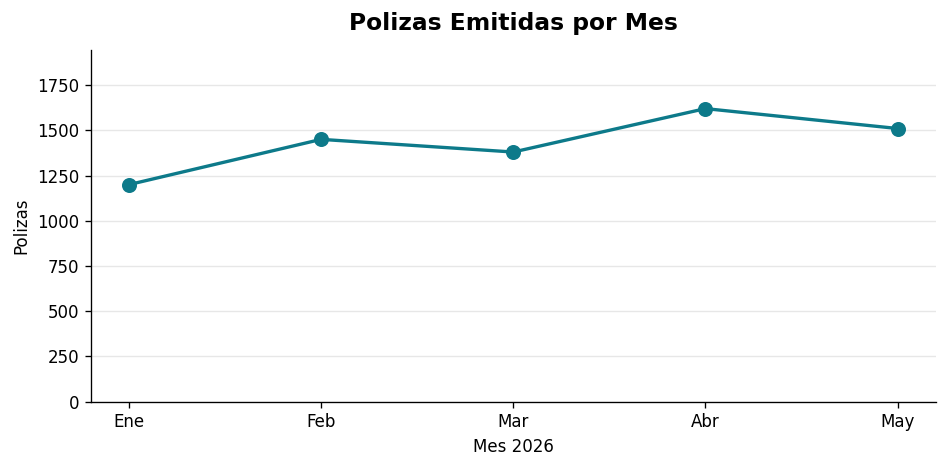

Figure: la hoja | Axes: el area de dibujo | Elementos: linea, titulo, ejes


In [124]:
# ── Hola mundo de Matplotlib ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

# Datos simples
meses = ['Ene','Feb','Mar','Abr','May']
polizas = [1200, 1450, 1380, 1620, 1510]

ax.plot(meses, polizas, marker='o', color='#0D7A8A', linewidth=2, markersize=8)

# Personalizar
ax.set_title('Polizas Emitidas por Mes', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Mes 2026')
ax.set_ylabel('Polizas')
ax.set_ylim(0, max(polizas)*1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print('Figure: la hoja | Axes: el area de dibujo | Elementos: linea, titulo, ejes')

<a id='graficas'></a>
### Las 4 Graficas sobre la Tabla Maestra

/var/folders/0x/kxtns7515ps4lbrgywb868nw0000gn/T/ipykernel_71467/2128170337.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen = df.groupby('ramo')['prima_total'].sum().sort_values()


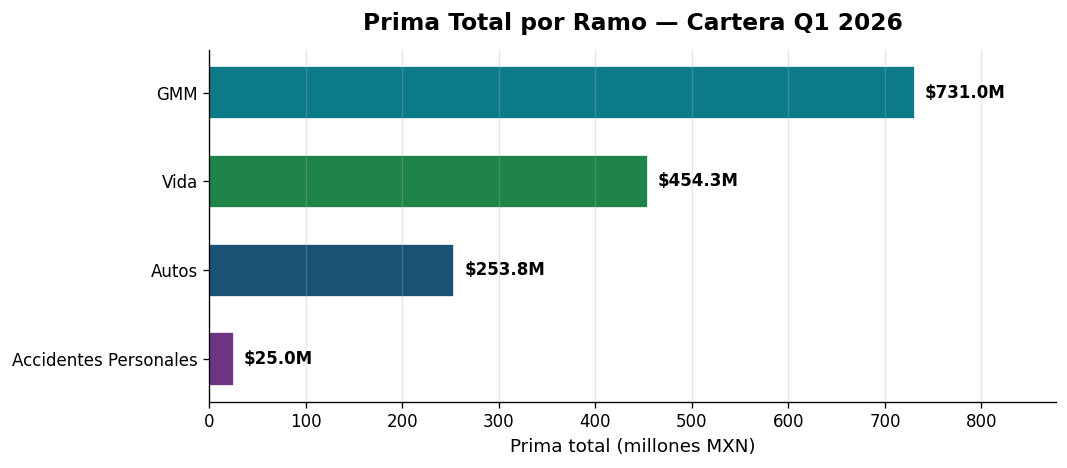

In [125]:
# ── Grafica 1: Prima total por ramo (barras horizontales) ────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

resumen = df.groupby('ramo')['prima_total'].sum().sort_values()

COLORES = {'GMM':'#0D7A8A','Autos':'#1A5276',
           'Vida':'#1E8449','Accidentes Personales':'#6C3483'}
colores_barras = [COLORES.get(r, '#888888') for r in resumen.index]

bars = ax.barh(resumen.index, resumen.values / 1_000_000,
               color=colores_barras, height=0.6, edgecolor='white')

ax.bar_label(bars, fmt='$%.1fM', padding=6, fontsize=10, fontweight='bold')
ax.set_xlabel('Prima total (millones MXN)', fontsize=11)
ax.set_title('Prima Total por Ramo — Cartera Q1 2026',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0, resumen.max()/1_000_000 * 1.2)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

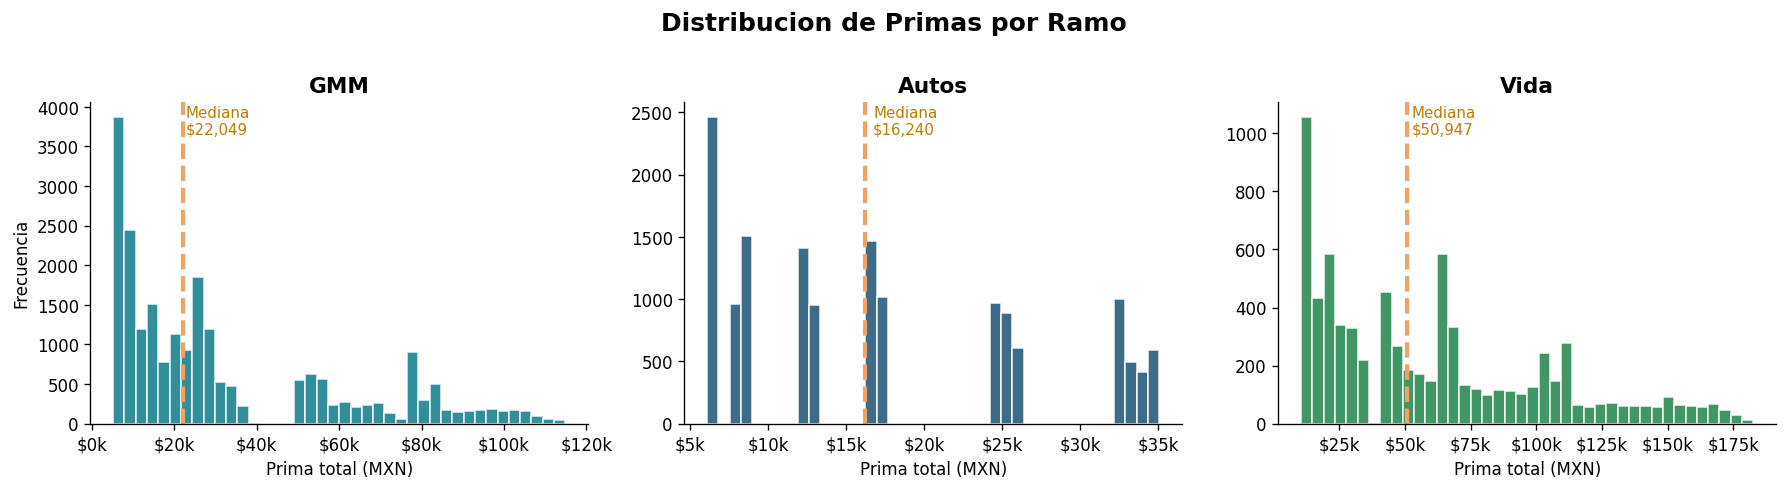

In [126]:
# ── Grafica 2: Distribucion de primas por ramo (histogramas) ─────────────────
ramos_principales = ['GMM', 'Autos', 'Vida']
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, ramo in zip(axes, ramos_principales):
    datos = df[df['ramo'] == ramo]['prima_total'].dropna()

    ax.hist(datos, bins=40, color=COLORES.get(ramo,'gray'),
            edgecolor='white', alpha=0.85)

    mediana = datos.median()
    ax.axvline(mediana, color='#F4A261', linewidth=2.5, linestyle='--')
    ax.text(mediana*1.03, ax.get_ylim()[1]*0.9,
            f'Mediana\n${mediana:,.0f}', fontsize=9, color='#C47B00')

    ax.set_title(ramo, fontsize=13, fontweight='bold')
    ax.set_xlabel('Prima total (MXN)', fontsize=10)
    ax.set_ylabel('Frecuencia' if ax == axes[0] else '')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

fig.suptitle('Distribucion de Primas por Ramo', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/var/folders/0x/kxtns7515ps4lbrgywb868nw0000gn/T/ipykernel_71467/2021984316.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([df['fecha_emision'].dt.to_period('M'), 'ramo'])
/var/folders/0x/kxtns7515ps4lbrgywb868nw0000gn/T/ipykernel_71467/2021984316.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ramo, grupo in por_mes_ramo.groupby('ramo'):


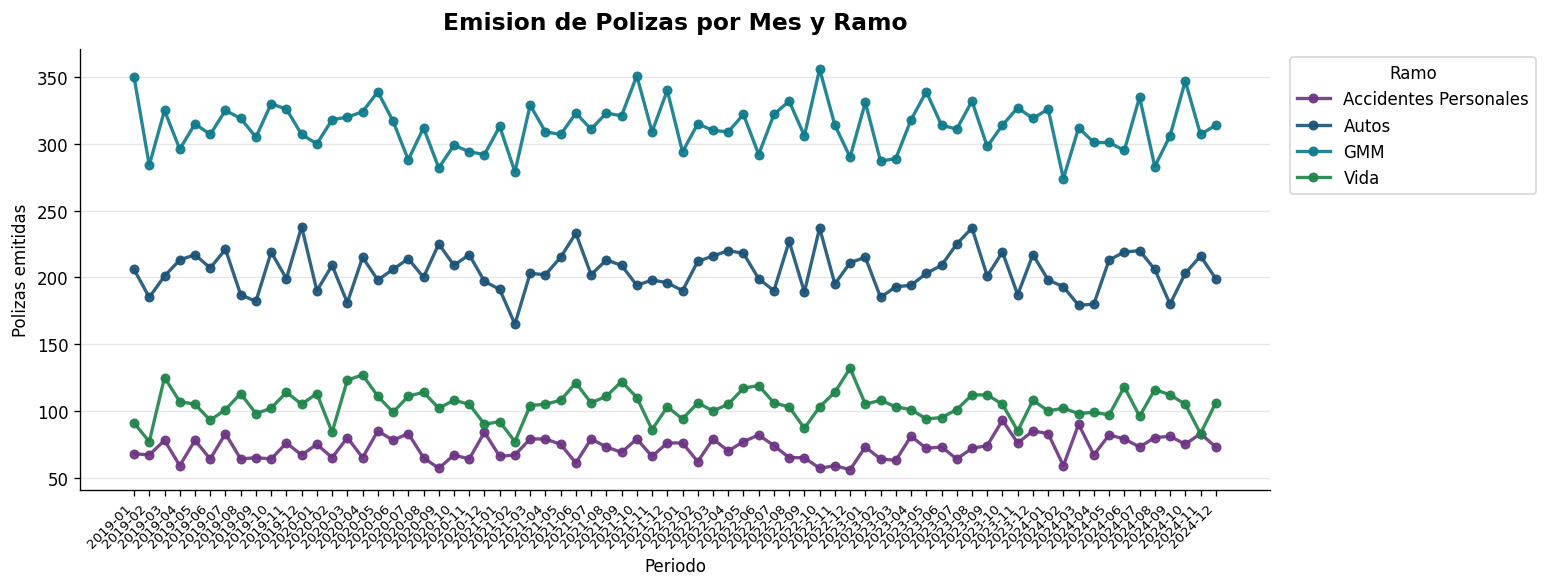

In [127]:
# ── Grafica 3: Emision de polizas por mes y ramo (lineas) ────────────────────
por_mes_ramo = (
    df.groupby([df['fecha_emision'].dt.to_period('M'), 'ramo'])
    .size()
    .reset_index(name='polizas')
)
por_mes_ramo['periodo'] = por_mes_ramo['fecha_emision'].astype(str)

fig, ax = plt.subplots(figsize=(13, 5))

for ramo, grupo in por_mes_ramo.groupby('ramo'):
    ax.plot(grupo['periodo'], grupo['polizas'],
            marker='o', label=ramo,
            color=COLORES.get(ramo, '#888888'),
            linewidth=2, markersize=5, alpha=0.9)

ax.set_title('Emision de Polizas por Mes y Ramo',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Periodo')
ax.set_ylabel('Polizas emitidas')
ax.legend(title='Ramo', bbox_to_anchor=(1.01,1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

/var/folders/0x/kxtns7515ps4lbrgywb868nw0000gn/T/ipykernel_71467/352983273.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ramo, grupo in muestra.groupby('ramo'):


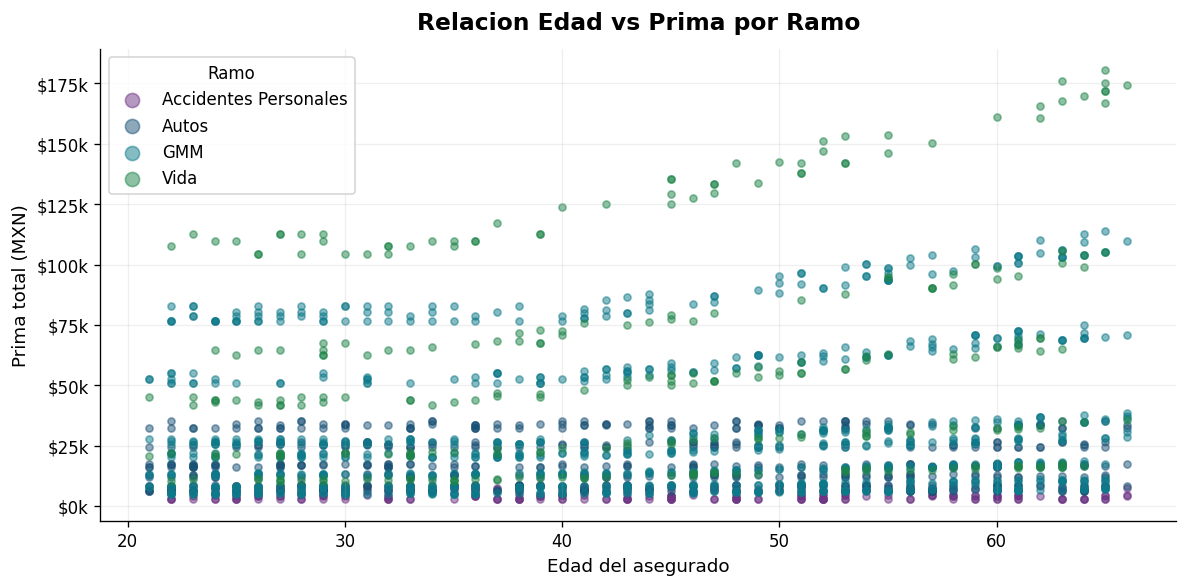

In [128]:
# ── Grafica 4: Edad vs Prima por ramo (scatter) ───────────────────────────────
# Usar muestra para no saturar el scatter
muestra = df.sample(min(2000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))

for ramo, grupo in muestra.groupby('ramo'):
    ax.scatter(
        grupo['edad'], grupo['prima_total'],
        label=ramo, alpha=0.5, s=18,
        color=COLORES.get(ramo, '#888888')
    )

ax.set_title('Relacion Edad vs Prima por Ramo',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Edad del asegurado', fontsize=11)
ax.set_ylabel('Prima total (MXN)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
ax.legend(title='Ramo', markerscale=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [129]:

import os

# Crear carpeta si no existe
os.makedirs('../sesion_10/datos', exist_ok=True)

# Guardar parquet
df.to_parquet(
    '../sesion_10/datos/cartera_q1_2026_final.parquet',
    index=False
)

print('Tabla final guardada')

df.to_parquet('../sesion_10/datos/cartera_q1_2026_final.parquet', index=False)
print('Tabla final')

Tabla final guardada
Tabla final


---
<a id='ejercicio'></a>
## Ejercicio Integrador

Usando la tabla maestra que construimos hoy:

**1.** Con `pipe()` construye un pipeline de 3 pasos:
solo polizas activas → agregar columna `loss_ratio` → filtrar `loss_ratio > 0`

**2.** Usa `query()` para encontrar las pólizas GMM con `nivel_riesgo >= 'MEDIO'`
y `prima_total > 5000`. ¿Cuántas son? ¿Cuál es su prima promedio?

**3.** Con `crosstab()` calcula el porcentaje de pólizas en nivel ALTO por estado.
¿Cuál estado tiene mayor % de riesgo alto?

**4.** Crea una figura con 2 subgráficas lado a lado:
- Izquierda: barras con prima promedio por `nivel_riesgo` (usa los 3 niveles ordenados)
- Derecha: barras con número de pólizas por `cuartil_prima`


[1] Pipeline con pipe()
  Polizas resultantes: 0

[2] Query GMM riesgo MEDIO+
  Polizas encontradas: 6,845
  Prima promedio: $31,957.34

[3] Crosstab riesgo alto por estado
nivel_riesgo      BAJO  MEDIO  ALTO
estado                             
Baja California  68.79  26.52  4.69
CDMX             69.47  25.53  5.00
Chihuahua        69.40  25.04  5.55
Coahuila         70.17  24.36  5.47
Estado de Mexico 68.74  25.60  5.66
Guanajuato       70.39  24.47  5.14
Jalisco          70.41  24.58  5.01
Michoacan        69.95  24.80  5.25
Nuevo Leon       70.07  24.41  5.52
Puebla           70.34  24.54  5.12
Queretaro        68.18  26.80  5.02
Sonora           69.26  25.36  5.38
Tamaulipas       70.49  24.96  4.55
Veracruz         70.55  24.33  5.12
Yucatan          70.71  24.14  5.15

  Estado con mayor % ALTO: Estado de Mexico (5.66%)

[4] Graficas


/var/folders/0x/kxtns7515ps4lbrgywb868nw0000gn/T/ipykernel_71467/222822723.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('nivel_riesgo')['prima_total']


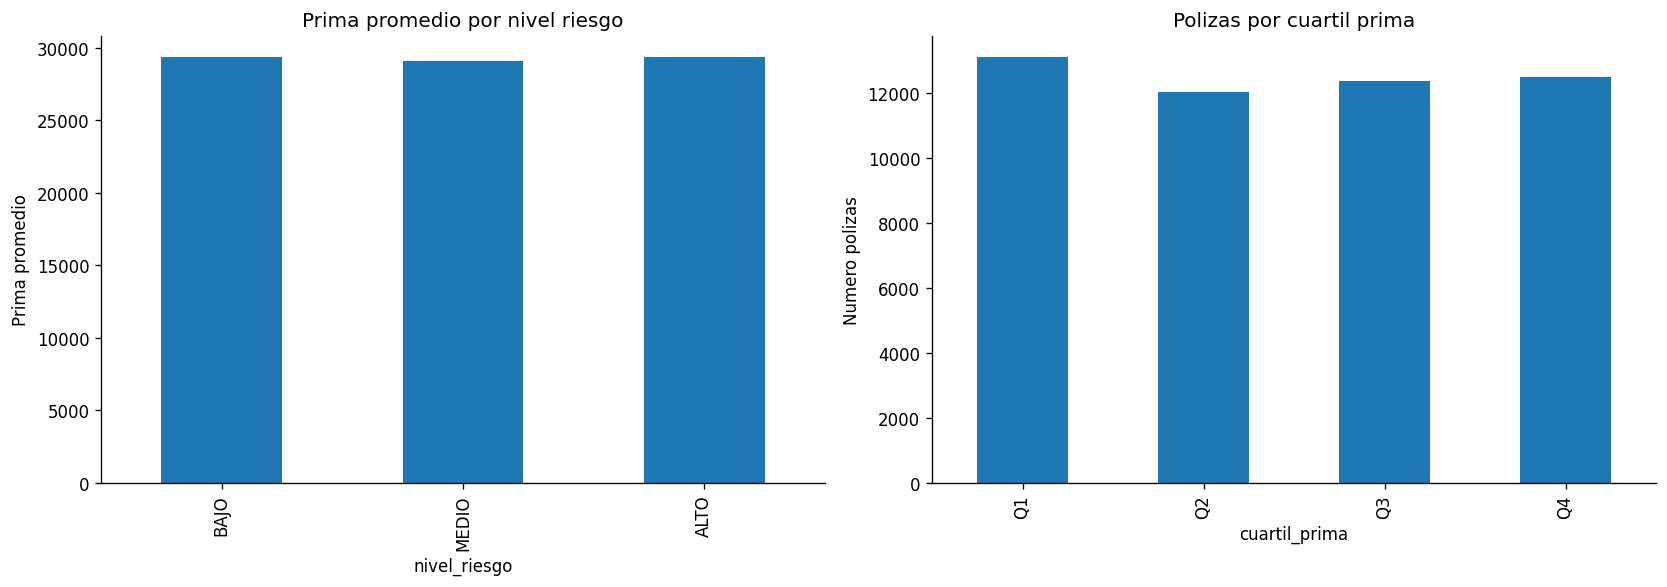

In [130]:

import matplotlib.pyplot as plt

# 1. Pipeline con pipe()

print("\n[1] Pipeline con pipe()")

pipeline_df = (
    df
    .pipe(lambda x: x[x['status_poliza'] == 'Activa'])
    .pipe(
        lambda x: x.assign(
            loss_ratio=x['monto_pagado'] / x['prima_total']
        )
    )
    .pipe(lambda x: x[x['loss_ratio'] > 0])
)

print(f"  Polizas resultantes: {len(pipeline_df):,}")


# 2. Query()

print("\n[2] Query GMM riesgo MEDIO+")

gmm_riesgo = df.query(
    "ramo == 'GMM' and nivel_riesgo >= 'MEDIO' and prima_total > 5000"
)

print(f"  Polizas encontradas: {len(gmm_riesgo):,}")

print(
    f"  Prima promedio: "
    f"${gmm_riesgo['prima_total'].mean():,.2f}"
)

# 3. Crosstab()

print("\n[3] Crosstab riesgo alto por estado")

tabla_riesgo = pd.crosstab(
    df['estado'],
    df['nivel_riesgo'],
    normalize='index'
) * 100

tabla_riesgo = tabla_riesgo.round(2)

print(tabla_riesgo)

estado_max = tabla_riesgo['ALTO'].idxmax()

pct_max = tabla_riesgo['ALTO'].max()

print(
    f"\n  Estado con mayor % ALTO: "
    f"{estado_max} ({pct_max:.2f}%)"
)

# 4. Visualizaciones

print("\n[4] Graficas")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: prima promedio por nivel riesgo

orden = ['BAJO', 'MEDIO', 'ALTO']

prima_riesgo = (
    df.groupby('nivel_riesgo')['prima_total']
    .mean()
    .reindex(orden)
)

prima_riesgo.plot(
    kind='bar',
    ax=ax[0]
)

ax[0].set_title('Prima promedio por nivel riesgo')
ax[0].set_ylabel('Prima promedio')

# Derecha: numero polizas por cuartil

df['cuartil_prima'] = pd.qcut(
    df['prima_total'],
    4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

df['cuartil_prima'].value_counts().sort_index().plot(
    kind='bar',
    ax=ax[1]
)

ax[1].set_title('Polizas por cuartil prima')
ax[1].set_ylabel('Numero polizas')

plt.tight_layout()
plt.show()

---
## Resumen Sesion 9

| Concepto | Lo que aprendimos |
|---------|------------------|
| **Joins en cascada** | Tabla maestra desde 4 fuentes — verificar shape y NaN en cada paso |
| **assign()** | Encadenar columnas nuevas con lambdas sin variables intermedias |
| **pipe()** | Pipeline legible: cada funcion recibe y devuelve DataFrame |
| **query()** | Filtros como texto legible — con variables Python usando @ |
| **qcut()** | Rangos por cuartiles — mismo N de filas en cada grupo |
| **Categorical** | Orden definido: BAJO < MEDIO < ALTO — funciona en filtros y sort |
| **crosstab()** | Tabla de contingencia rapida con normalize |
| **str.extract()** | Regex sobre columnas para extraer partes estructuradas |
| **Matplotlib** | Figure > Axes > elementos — la jerarquia base |
| **4 graficas** | Barras, histograma por grupo, linea temporal, scatter |

**Proxima sesion: Viernes 8 de mayo — otro profesor — T6 formal.**
Usaran la misma tabla maestra que construimos hoy.

```bash
git add sesion9_M1_notebook.ipynb
git commit -m "Sesion 9: tabla maestra joins tips matplotlib"
git push
```

---
*Diplomado ML en Seguros · Facultad de Ciencias, UNAM · 2026*